In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [33]:
start = '2020-01-01'
end = '2026-04-01'
stock = 'GOOG'

data = yf.download(stock, start, end)

[*********************100%***********************]  1 of 1 completed


In [34]:
data.reset_index(inplace=True)

In [35]:
data

Price,Date,Close,High,Low,Open,Volume
Ticker,,GOOG,GOOG,GOOG,GOOG,GOOG
0,2020-01-02,67.811760,67.849944,66.531272,66.531272,28132000
1,2020-01-03,67.478989,68.066171,66.729345,66.844201,23728000
2,2020-01-06,69.142845,69.256407,66.950343,66.950343,34646000
3,2020-01-07,69.099693,69.578262,68.952896,69.327824,30054000
4,2020-01-08,69.644226,70.004269,68.975711,69.037203,30560000
...,...,...,...,...,...,...
1564,2026-03-25,289.589996,294.660004,287.369995,292.149994,22343000
1565,2026-03-26,280.739990,286.515015,279.049988,286.190002,29281200
1566,2026-03-27,273.760010,279.089996,273.480011,277.399994,25703300


In [36]:
ma_100_days = data.Close.rolling(100).mean()

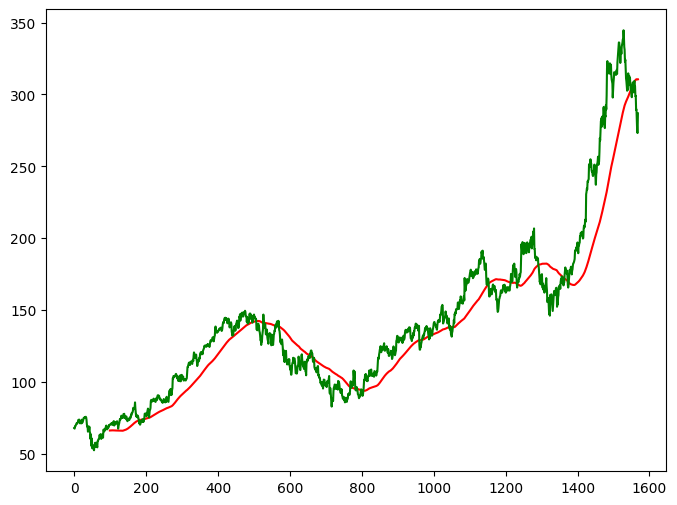

In [37]:
plt.figure(figsize=(8,6))
plt.plot(ma_100_days, 'r')
plt.plot(data.Close, 'g')
plt.show()

In [38]:
ma_200_days = data.Close.rolling(200).mean()

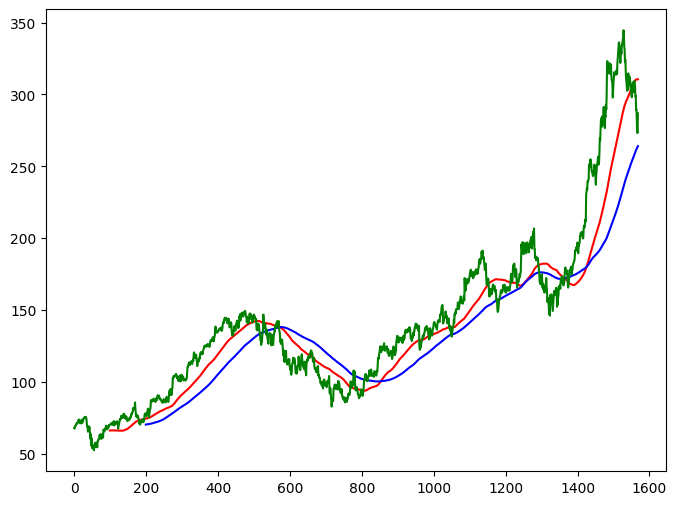

In [39]:
plt.figure(figsize=(8,6))
plt.plot(ma_100_days, 'r')
plt.plot(ma_200_days,'b')
plt.plot(data.Close,'g')
plt.show()

In [40]:
data.dropna(inplace=True)

In [41]:
data_train = pd.DataFrame(data.Close[0: int(len(data)*0.80)])
data_test = pd.DataFrame(data.Close[int(len(data)*0.80): len(data)])

In [42]:
data_train.shape[0]

1255

In [43]:
data_test.shape[0]

314

In [44]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [45]:
data_train_scale = scaler.fit_transform(data_train)

In [46]:
x = []
y = []

for i in range(100, data_train_scale.shape[0]):
    x.append(data_train_scale[i-100:i])
    y.append(data_train_scale[i,0])
    

In [47]:
x, y = np.array(x), np.array(y)

In [48]:
from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential

In [49]:
model = Sequential()
model.add(LSTM(units = 50, activation = 'relu', return_sequences = True,
               input_shape = ((x.shape[1],1))))
model.add(Dropout(0.2))

model.add(LSTM(units = 60, activation='relu', return_sequences = True))
model.add(Dropout(0.3))

model.add(LSTM(units = 80, activation = 'relu', return_sequences = True))
model.add(Dropout(0.4))

model.add(LSTM(units = 120, activation = 'relu'))
model.add(Dropout(0.5))

model.add(Dense(units =1))

In [50]:
model.compile(optimizer = 'adam', loss = 'mean_squared_error')

In [51]:
model.fit(x,y, epochs = 50, batch_size =32, verbose =1)

Epoch 1/50
37/37 [==============================] - 28s 272ms/step - loss: 0.0549
Epoch 2/50
37/37 [==============================] - 10s 259ms/step - loss: 0.0123
Epoch 3/50
37/37 [==============================] - 7s 187ms/step - loss: 0.0098
Epoch 4/50
37/37 [==============================] - 13s 341ms/step - loss: 0.0082
Epoch 5/50
37/37 [==============================] - 11s 292ms/step - loss: 0.0085
Epoch 6/50
37/37 [==============================] - 8s 220ms/step - loss: 0.0084
Epoch 7/50
37/37 [==============================] - 8s 211ms/step - loss: 0.0080
Epoch 8/50
37/37 [==============================] - 12s 305ms/step - loss: 0.0079
Epoch 9/50
37/37 [==============================] - 12s 334ms/step - loss: 0.0072
Epoch 10/50
37/37 [==============================] - 11s 297ms/step - loss: 0.0076
Epoch 11/50
37/37 [==============================] - 13s 341ms/step - loss: 0.0070
Epoch 12/50
37/37 [==============================] - 12s 336ms/step - loss: 0.0080
Epoch 13/50
37/3

In [52]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_4 (LSTM)               (None, 100, 50)           10400     
                                                                 
 dropout_4 (Dropout)         (None, 100, 50)           0         
                                                                 
 lstm_5 (LSTM)               (None, 100, 60)           26640     
                                                                 
 dropout_5 (Dropout)         (None, 100, 60)           0         
                                                                 
 lstm_6 (LSTM)               (None, 100, 80)           45120     
                                                                 
 dropout_6 (Dropout)         (None, 100, 80)           0         
                                                                 
 lstm_7 (LSTM)               (None, 120)              

In [53]:
pas_100_days = data_train.tail(100)

In [54]:
data_test = pd.concat([pas_100_days, data_test], ignore_index=True)

In [55]:
data_test_scale  =  scaler.fit_transform(data_test)

In [56]:
x = []
y = []

for i in range(100, data_test_scale.shape[0]):
    x.append(data_test_scale[i-100:i])
    y.append(data_test_scale[i,0])
x, y = np.array(x), np.array(y)

In [57]:
y_predict = model.predict(x)

10/10 [==============================] - 3s 117ms/step


In [58]:
scale =1/scaler.scale_

In [59]:
y_predict = y_predict*scale

In [60]:
y = y*scale

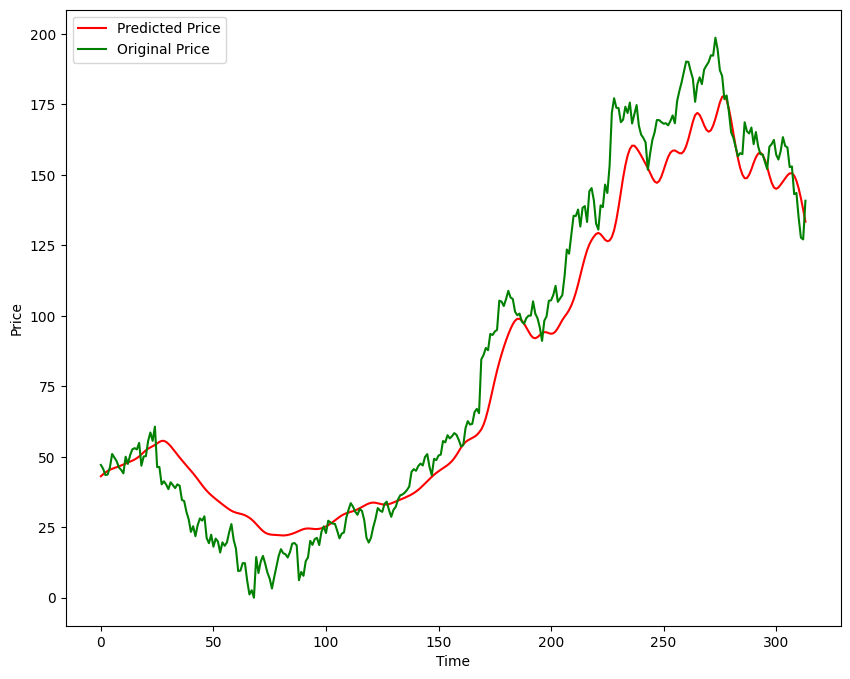

In [61]:
plt.figure(figsize=(10,8))
plt.plot(y_predict, 'r', label = 'Predicted Price')
plt.plot(y, 'g', label = 'Original Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

In [62]:
model.save('Stock Predictions Model.keras')